In [1]:
"""
=============================================================================
EBOLA SEIDdIndFR — DECLARED vs UNDECLARED INFECTIOUS SPLIT
=============================================================================
  Data source: Confirmed cases, confirmed deaths, contacts listed
  
  Model structure:
    S  → E (exposed/contacts) → Id  (declared infectious) → R + Dd (declared deaths)
                             → Ind (undeclared infectious) → R + F → Dnd
  
  Fitting targets:
    - Confirmed cases (daily new) fit to Id incidence
    - Confirmed deaths (daily new) fit to Dd rate
    - Contacts listed (cumulative) fit to cumulative E
  
  Optimizer: Differential Evolution (global, gradient-free)
  Loss: Weighted Poisson NLL on all three observables
  
  Model equations:
    dS   = -(beta_I*S*Id + beta_F*S*F) / N
    dE   = (beta_I*S*Id + beta_F*S*F) / N - alpha*E
    dId  = delta1 * alpha*E - (gamma_i + mu)*Id
    dInd = (1-delta1) * alpha*E - (gamma_i + mu)*Ind
    dF   = mu*Ind - gamma_f*F
    dR   = gamma_i * (Id + Ind)
    dDd  = mu * Id
    dDnd = gamma_f * F
=""="="="="="="="="="="="="="="="="="="="="="="="="="="="="="="="="="="="="="=
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution, brentq
from datetime import datetime, timedelta
import warnings, os
warnings.filterwarnings("ignore")

np.random.seed(42)


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# 1.  DATA LOADING
# ══════════════════════════════════════════════════════════════════════════

# Load data
df= pd.read_csv('your_location/insp_smoothed_incidence.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

# Observables for fitting
obs_cases    = df['smoothed_confirmed_cases'].values.astype(float)
obs_deaths   = df['smoothed_confirmed_deaths'].values.astype(float)
obs_dates    = df['Date'].tolist()
n_days       = len(df)
DATA_START   = df['Date'].iloc[0]

print("="*70)
print("DATA FOR CALIBRATION")
print("="*70)
print(df[['Date', 'smoothed_confirmed_cases', 'smoothed_confirmed_deaths']].to_string(index=False))
print("="*70)
print(f"Date range: {DATA_START.date()} to {obs_dates[-1].date()}")
print(f"Total days: {n_days}")
print("="*70)


DATA FOR CALIBRATION
      Date  smoothed_confirmed_cases  smoothed_confirmed_deaths
2026-05-14                 12.750000                   1.000000
2026-05-17                 12.800000                   1.200000
2026-05-18                 13.833333                   1.500000
2026-05-19                 13.000000                   1.428571
2026-05-20                 13.285714                   0.857143
2026-05-21                 13.142857                   0.857143
2026-05-22                 10.428571                   1.142857
2026-05-23                 10.000000                   1.857143
2026-05-24                  8.714286                   1.571429
2026-05-25                 18.142857                   1.142857
2026-05-26                 24.571429                   4.571429
2026-05-27                 25.857143                   4.571429
2026-05-28                 30.857143                   5.428571
2026-05-29                 34.000000                   6.857143
2026-05-30         

In [3]:
# ══════════════════════════════════════════════════════════════════════════
# 2.  MODEL
# ══════════════════════════════════════════════════════════════════════════

N = 1500000   # at-risk population
r=1# isolation parameter
class SEIDdIndFR:
    """
    8-compartment Ebola model with declared (Id) and undeclared (Ind) infectious.
    
    State vector: [S, E, Id, Ind, F, R, Dd, Dnd]
    
    Parameters
    ----------
    beta_I   : transmission rate from declared infectious (Id)
    beta_F   : transmission rate from funeral/corpse compartment (F)
    alpha    : 1 / incubation period (days)
    gamma_i  : 1 / infectious period for survivors (both Id and Ind)
    delta1   : fraction of exposed that become declared (Id)
    mu       : disease-induced death rate (1 / time from infectious to death)
    gamma_f  : 1 / corpse infectious duration (days)
    """
    def __init__(self, beta_Id,beta_Ind, beta_F, alpha, gamma_i, delta1, mu, gamma_f):
        self.p = (beta_Id,beta_Ind, beta_F, alpha, gamma_i, delta1, mu, gamma_f)
        (self.beta_Id,self.beta_Ind, self.beta_F, self.alpha, self.gamma_i,
         self.delta1, self.mu, self.gamma_f) = self.p

    def __call__(self, t, y):
        S, E, Id, Ind, F, R, Dd, Dnd = y
        betaId,betaInd, betaF, alpha, gamma_i, mu, delta1, gamma_f = self.p

        lam = (r*betaId * S * Id + betaInd * S * Ind + betaF * S * F) / N  # force of infection
        return [
            -lam,
            lam  - alpha * E,
            delta1       * alpha * E - (gamma_i + mu) * Id,
            (1 - delta1) * alpha * E - (gamma_i + mu) * Ind,
            mu * Ind - gamma_f * F,
            gamma_i * (Id + Ind),
            mu * Id,
            gamma_f * F
        ]

    def run(self, t_span, y0, t_eval):
        sol = solve_ivp(self, t_span, y0, method="RK45",
                        t_eval=t_eval, rtol=1e-8, atol=1e-10)
        return sol if sol.success else None

    def incidence_Id(self, sol):
        """Daily new declared cases = delta1 * alpha * E"""
        return self.delta1 * self.alpha * sol.y[1]

    def death_rate_Dd(self, sol):
        """Daily declared deaths = mu * Id"""
        return self.mu * sol.y[2]
    
    def incidence_Ind(self, sol):
        """Daily new declared cases = delta1 * alpha * E"""
        return (1 - self.delta1) * self.alpha  * sol.y[1]

    def R0(self):
        """
        Basic reproduction number.
        Two routes:
          - declared: beta_I * delta1 / (gamma_i + mu)
          - undeclared→funeral: beta_F * (1-delta1) * mu / (gamma_f * (gamma_i + mu))
        """
        
        sigma = self.gamma_i + self.mu    # total exit rate from infectious classes
        R0_Id  = self.beta_Id * r / sigma                                          # from Id + Ind
        R0_Ind  = self.beta_Ind / sigma                                          # from Id + Ind

        R0_F  = self.beta_F * (1 + self.mu / sigma) / self.gamma_f           # from F (Ind→F only)
        R0    = R0_Id + R0_Ind + R0_F
        return R0


In [4]:
# ══════════════════════════════════════════════════════════════════════════
# 3.  PARAMETER BOUNDS
# ══════════════════════════════════════════════════════════════════════════

BOUNDS = [
    (0.01, 0.5),   # beta_Id
    (0.05, 0.5),   # beta_Ind
    (0.05, 0.2),   # beta_F
    (1/21, 1/2),    # alpha (incubation 2-21 days)
    (1/11, 1/6),    # gamma_i (infectious period 5-21 days)
    (0, 1),   # delta1 (fraction declared) was (0.2,0.3)
    (1/16, 1/6),    # mu 
    (1/3, 1.00),    # gamma_f (corpse window 1-3 days)
    (0.0, 5),     # log_E0 (initial exposed)
    (0.0, 5),     # log_Id0 (initial declared infectious)
    (0.0, 5),     # log_Ind0 (initial undeclared infectious)
]

In [5]:
# ══════════════════════════════════════════════════════════════════════════
# 4.  OBJECTIVE FUNCTION
# ══════════════════════════════════════════════════════════════════════════

def pnll(obs, pred):
    """Poisson negative log-likelihood for count data."""
    pred = np.maximum(np.asarray(pred, float), 1e-9)
    obs = np.asarray(obs, float)
    return -np.sum(obs * np.log(pred) - pred)

from scipy.special import gammaln
import numpy as np

def nb_nll(obs, pred, k=10.0):
    """
    Negative Binomial NLL.
    
    pred = mean (mu)
    k    = dispersion parameter
    """
    obs = np.asarray(obs, float)
    pred = np.maximum(np.asarray(pred, float), 1e-9)

    loglik = (
        gammaln(obs + k)
        - gammaln(k)
        - gammaln(obs + 1)
        + k * np.log(k / (k + pred))
        + obs * np.log(pred / (k + pred))
    )

    return -np.sum(loglik)

def gaussian_nll(obs, pred):

    obs = np.asarray(obs, float)
    pred = np.asarray(pred, float)

    residuals = obs - pred

    sigma = np.std(residuals)

    sigma = max(sigma, 1e-6)

    n = len(obs)

    return (
        n*np.log(sigma)
        + np.sum(residuals**2)/(2*sigma**2)
    )

def mse(obs, pred):
    obs = np.asarray(obs, float)
    pred = np.asarray(pred, float)
    return np.mean((obs - pred)**2)

def build_model(params):
    """Unpack parameters and build initial conditions."""
    bId, bInd, bF, alph, gi, d1, mu, gf, le0, lid0, lind0 = params
    E0 = np.exp(le0)
    Id0 = np.exp(lid0)
    Ind0 = np.exp(lind0)
    S0 = N - E0 - Id0 - Ind0
    
    if S0 <= 0:
        return None, None, False
    
    model = SEIDdIndFR(bId,bInd, bF, alph, gi, d1, mu, gf)
    y0 = [S0, E0, Id0, Ind0, 0., 0., 0., 0.]
    return model, y0, True


def objective(params):
    """
    Fit to three observables:
      1. Confirmed cases (daily new) → Id incidence
      2. Confirmed deaths (daily new) → Dd rate
    """
    model, y0, ok = build_model(params)
    if not ok:
        return 1e12
    
    t_eval = np.arange(n_days, dtype=float)
    sol = model.run((0., float(n_days - 1)), y0, t_eval)
    if sol is None:
        return 1e12
    S, E, Id, Ind, F, R, Dd, Dnd = sol.y
    # Predicted observables
    pred_cases = model.incidence_Id(sol)
    pred_deaths = model.death_rate_Dd(sol)
    # Losses
    """nll_cases = pnll(obs_cases, np.maximum(pred_cases, 1e-6))
    nll_deaths = pnll(obs_deaths, np.maximum(pred_deaths, 1e-6))"""
    nll_cases = nb_nll(obs_cases, pred_cases, k=10)
    nll_deaths = nb_nll(obs_deaths, pred_deaths, k=10)
    """nll_cases = gaussian_nll(obs_cases, pred_cases)
    nll_deaths = gaussian_nll(obs_deaths, pred_deaths)
    nll_cases= mse(obs_cases, pred_cases)
    nll_deaths= mse(obs_deaths, pred_deaths)"""
    # Weighted sum (equal weight for now)
    return nll_cases + nll_deaths 


In [7]:
# ══════════════════════════════════════════════════════════════════════════
# 5.  CALIBRATION
# ══════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("RUNNING DIFFERENTIAL EVOLUTION CALIBRATION...")
print("="*70)

result = differential_evolution(
    objective, BOUNDS,
    seed=42, maxiter=2000, popsize=15,
    tol=1e-9, mutation=(0.5, 1.5), recombination=0.8,
    polish=True, disp=True, workers=-1
)

print(f"\nCalibration complete. NLL = {result.fun:.4f}\n")

# Unpack best-fit parameters
(bId_hat,bInd_hat, bF_hat, alpha_hat, gamma_i_hat, delta1_hat, mu_hat, gamma_f_hat,
 le0_hat, lid0_hat, lind0_hat) = result.x

E0_hat = np.exp(le0_hat)
Id0_hat = np.exp(lid0_hat)
Ind0_hat = np.exp(lind0_hat)
S0_hat = N - E0_hat - Id0_hat - Ind0_hat




RUNNING DIFFERENTIAL EVOLUTION CALIBRATION...
differential_evolution step 1: f(x)= 233.25487668308153
differential_evolution step 2: f(x)= 233.25487668308153
differential_evolution step 3: f(x)= 226.48848034963896
differential_evolution step 4: f(x)= 226.48848034963896
differential_evolution step 5: f(x)= 226.48848034963896
differential_evolution step 6: f(x)= 218.91886777570545
differential_evolution step 7: f(x)= 212.55160700893487
differential_evolution step 8: f(x)= 204.51294383113856
differential_evolution step 9: f(x)= 204.51294383113856
differential_evolution step 10: f(x)= 203.3979124459845
differential_evolution step 11: f(x)= 203.3979124459845
differential_evolution step 12: f(x)= 203.3979124459845
differential_evolution step 13: f(x)= 201.33586988422374
differential_evolution step 14: f(x)= 201.33586988422374
differential_evolution step 15: f(x)= 200.49274338011742
differential_evolution step 16: f(x)= 198.68356442536867
differential_evolution step 17: f(x)= 198.68356442536

In [8]:

model_hat = SEIDdIndFR(bId_hat,bInd_hat, bF_hat, alpha_hat, gamma_i_hat,
                       delta1_hat, mu_hat, gamma_f_hat)
R0_hat = model_hat.R0()

print("="*70)
print("BEST-FIT PARAMETERS")
print("="*70)
print(f"  beta_Id       = {bId_hat:.4f}  (declared contact rate)")
print(f"  beta_Ind       = {bInd_hat:.4f}  (non-declared contact rate)")
print(f"  beta_F       = {bF_hat:.4f}  (funeral contact rate)")
print(f"  alpha        = {alpha_hat:.4f}  → incubation {1/alpha_hat:.1f} days")
print(f"  gamma_i      = {gamma_i_hat:.4f}  → infectious period {1/gamma_i_hat:.1f} days")
print(f"  delta1       = {delta1_hat:.4f}  ({delta1_hat*100:.1f}% declared)")
print(f"  mu           = {mu_hat:.4f}  → death time {1/mu_hat:.1f} days")
print(f"  gamma_f      = {gamma_f_hat:.4f}  → corpse window {1/gamma_f_hat:.1f} days")
print(f"  E0           = {E0_hat:.2f}")
print(f"  Id0          = {Id0_hat:.2f}")
print(f"  Ind0         = {Ind0_hat:.2f}")
print(f"  R0           = {R0_hat:.3f}")
print("="*70)


BEST-FIT PARAMETERS
  beta_Id       = 0.0100  (declared contact rate)
  beta_Ind       = 0.3887  (non-declared contact rate)
  beta_F       = 0.2000  (funeral contact rate)
  alpha        = 0.5000  → incubation 2.0 days
  gamma_i      = 0.0909  → infectious period 11.0 days
  delta1       = 0.2190  (21.9% declared)
  mu           = 0.1402  → death time 7.1 days
  gamma_f      = 0.6336  → corpse window 1.6 days
  E0           = 106.15
  Id0          = 3.95
  Ind0         = 148.41
  R0           = 2.232


In [9]:
# ══════════════════════════════════════════════════════════════════════════
# 6.  FIT TRAJECTORIES
# ══════════════════════════════════════════════════════════════════════════

t_data = np.arange(n_days, dtype=float)
sol_fit = model_hat.run((0., float(n_days - 1)),
                        [S0_hat, E0_hat, Id0_hat, Ind0_hat, 0., 0., 0., 0.],
                        t_data)

fit_cases = model_hat.incidence_Id(sol_fit)
fit_deaths = model_hat.death_rate_Dd(sol_fit)

fit_cum_cases = np.cumsum(fit_cases)
fit_cum_deaths = np.cumsum(fit_deaths)


In [10]:
# ══════════════════════════════════════════════════════════════════════════
# 7.  GOODNESS OF FIT
# ══════════════════════════════════════════════════════════════════════════

from sklearn.metrics import r2_score, mean_squared_error

r2_cases = r2_score(obs_cases, fit_cases)
r2_deaths = r2_score(obs_deaths, fit_deaths)

rmse_cases = np.sqrt(mean_squared_error(obs_cases, fit_cases))
rmse_deaths = np.sqrt(mean_squared_error(obs_deaths, fit_deaths))

print("\n" + "="*70)
print("FIT QUALITY")
print("="*70)
print(f"Confirmed cases (daily new):")
print(f"  R² = {r2_cases:.4f},  RMSE = {rmse_cases:.2f}")
print(f"\nConfirmed deaths (daily new):")
print(f"  R² = {r2_deaths:.4f},  RMSE = {rmse_deaths:.2f}")
print("="*70)



FIT QUALITY
Confirmed cases (daily new):
  R² = 0.2028,  RMSE = 9.80

Confirmed deaths (daily new):
  R² = 0.8102,  RMSE = 2.13


In [11]:
# ══════════════════════════════════════════════════════════════════════════
# 6.  t0 ESTIMATION  (forward shooting)
# ══════════════════════════════════════════════════════════════════════════
#
# Start from a single index case: Id=1, Ind=0, E=0.
# Integrate forward until Id(T) matches calibrated Id0.
# T days before DATA_START = estimated epidemic origin.

def Id_at_T(T):
    if T <= 0:
        return 1.0
    sol = solve_ivp(
        model_hat, (0, T),
        [N-1, 0, 1, 0, 0, 0, 0, 0],
        method='RK45', t_eval=[T],
        rtol=1e-8, atol=1e-10
    )
    return float(sol.y[2, -1])   # Id at time T

f_lo = Id_at_T(1)   - Id0_hat
f_hi = Id_at_T(120) - Id0_hat

if f_lo * f_hi < 0:
    days_before = brentq(lambda T: Id_at_T(T) - Id0_hat, 1, 120, xtol=0.1)
elif f_lo > 0:
    days_before = 0.0
else:
    days_before = 120.0

t0_date = DATA_START - timedelta(days=float(days_before))
print(f'\n  Estimated t0 : {t0_date.strftime("%d %B %Y")}')
print(f'  ({days_before:.1f} days before first confirmed report)')


  Estimated t0 : 14 January 2026
  (120.0 days before first confirmed report)


In [12]:
# ══════════════════════════════════════════════════════════════════════════
# 8.  PROJECTION (90 DAYS)
# ══════════════════════════════════════════════════════════════════════════

N_PROJ = 90
t_fine = np.linspace(0, N_PROJ, N_PROJ * 4 + 1)
sol_proj = model_hat.run((0., N_PROJ),
                         [S0_hat, E0_hat, Id0_hat, Ind0_hat, 0., 0., 0., 0.],
                         t_fine)

S_p, E_p, Id_p, Ind_p, F_p, R_p, Dd_p, Dnd_p = sol_proj.y
inc_p = model_hat.incidence_Id(sol_proj)
dead_p = model_hat.death_rate_Dd(sol_proj)
incnd_p = model_hat.incidence_Ind(sol_proj)

dt = t_fine[1] - t_fine[0]
cum_cases_p = np.cumsum(inc_p) * dt
cum_deaths_p = np.cumsum(dead_p) * dt
cum_casesnd_p = np.cumsum(incnd_p) * dt

proj_dates = [DATA_START + timedelta(days=float(t)) for t in t_fine]

# Find peaks
peak_inc_idx = np.argmax(inc_p)
peak_inc_date = proj_dates[peak_inc_idx]
peak_inc_val = inc_p[peak_inc_idx]

peak_Id_idx = np.argmax(Id_p)
peak_Id_date = proj_dates[peak_Id_idx]
peak_Id_val = Id_p[peak_Id_idx]


print(f"\nPeak declared incidence: {peak_inc_val:.1f} cases/day on {peak_inc_date.strftime('%d %b %Y')}")
print(f"Peak Id(t): {peak_Id_val:.0f} persons on {peak_Id_date.strftime('%d %b %Y')}")



Peak declared incidence: 665.7 cases/day on 12 Aug 2026
Peak Id(t): 1230 persons on 12 Aug 2026



Figure saved to ebola_fit_analysis.png


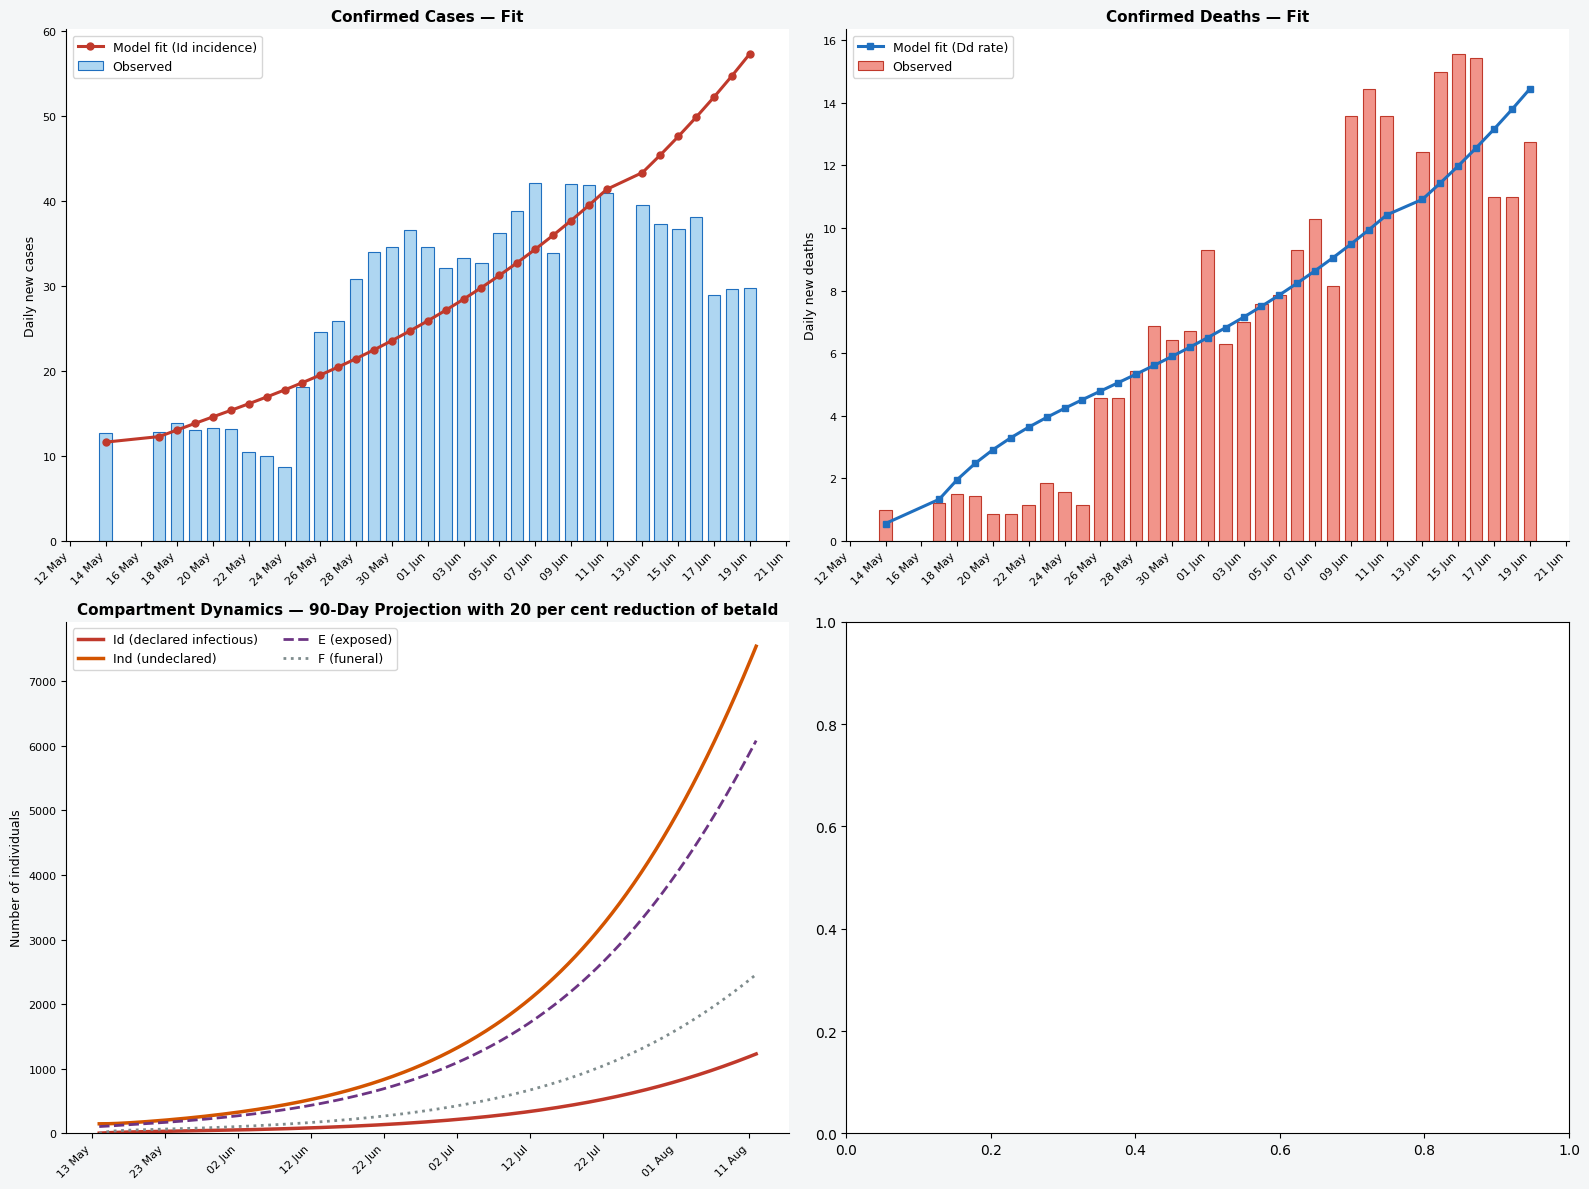

In [13]:
# ══════════════════════════════════════════════════════════════════════════
# 9.  PLOTTING
# ══════════════════════════════════════════════════════════════════════════

BLUE = '#1F6FBF'
LBLUE = '#AED6F1'
RED = '#C0392B'
LRED = '#F1948A'
GREEN = '#1A7A4A'
ORANGE = '#D35400'
GRAY = '#7F8C8D'
PURPLE = '#6C3483'

def style(ax, interval=2):
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=interval))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#F4F6F7')

# Plot 1: Confirmed cases fit
ax = axes[0, 0]
ax.bar(obs_dates, obs_cases, color=LBLUE, edgecolor=BLUE, lw=0.8, width=0.7, label='Observed')
ax.plot(obs_dates, fit_cases, 'o-', color=RED, lw=2.2, ms=5, label='Model fit (Id incidence)')
ax.set_title('Confirmed Cases — Fit', fontsize=11, fontweight='bold')
ax.set_ylabel('Daily new cases', fontsize=9)
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)
style(ax)

# Plot 2: Confirmed deaths fit
ax = axes[0, 1]
ax.bar(obs_dates, obs_deaths, color=LRED, edgecolor=RED, lw=0.8, width=0.7, label='Observed')
ax.plot(obs_dates, fit_deaths, 's-', color=BLUE, lw=2.2, ms=5, label='Model fit (Dd rate)')
ax.set_title('Confirmed Deaths — Fit', fontsize=11, fontweight='bold')
ax.set_ylabel('Daily new deaths', fontsize=9)
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)
style(ax)


# Plot 4: Compartment dynamics (projection)
ax = axes[1, 0]
ax.plot(proj_dates, Id_p, lw=2.5, color=RED, label='Id (declared infectious)')
ax.plot(proj_dates, Ind_p, lw=2.5, color=ORANGE, label='Ind (undeclared)')
ax.plot(proj_dates, E_p, lw=2, color=PURPLE, linestyle='--', label='E (exposed)')
ax.plot(proj_dates, F_p, lw=2, color=GRAY, linestyle=':', label='F (funeral)')
ax.set_title('Compartment Dynamics — 90-Day Projection with 20 per cent reduction of betaId', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of individuals', fontsize=9)
ax.legend(fontsize=9, ncol=2)
ax.set_ylim(bottom=0)
style(ax, interval=10)

plt.tight_layout()
plt.savefig('ebola_fit_analysis.png', dpi=150, bbox_inches='tight')
print("\nFigure saved to ebola_fit_analysis.png")
plt.show()


In [14]:
# ══════════════════════════════════════════════════════════════════════════
# 10. SUMMARY STATISTICS
# ══════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("EPIDEMIC PROJECTIONS (90 DAYS)")
print("="*70)
print(f"Peak incidence: {peak_inc_val:.0f} cases/day on {peak_inc_date.strftime('%d %b %Y')}")
print(f"Peak Id: {peak_Id_val:.0f} persons on {peak_Id_date.strftime('%d %b %Y')}")
print(f"Cumulative cases (day 30): {np.interp(30, t_fine, cum_cases_p):.0f}")
print(f"Cumulative deaths (day 30): {np.interp(30, t_fine, cum_deaths_p):.0f}")
print("="*70)



EPIDEMIC PROJECTIONS (90 DAYS)
Peak incidence: 666 cases/day on 12 Aug 2026
Peak Id: 1230 persons on 12 Aug 2026
Cumulative cases (day 30): 810
Cumulative deaths (day 30): 195


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. DEFINE PARAMETER RANGES (+/- 5%)
# ==========================================
p_opt = result.x
num_samples = 300  # Number of random sets to draw

# Calculate the exact -5% and +5% boundaries for each parameter
lower_5pc = p_opt * 0.95
upper_5pc = p_opt * 1.05

# Generate random samples from a uniform distribution within these bounds
# Resulting shape: (300, 5)
random_params = np.random.uniform(low=lower_5pc, high=upper_5pc, size=(num_samples, len(p_opt)))

# ==========================================
# 2. RUN MODEL FOR ALL RANDOM SAMPLES
# ==========================================
all_I_preds = []
all_D_preds = []
print(f"Running {num_samples} simulations with ±5% parameter variation...")

for params in random_params:
    bId_hat1,bInd_hat1, bF_hat1, alpha_hat1, gamma_i_hat1, delta1_hat1, mu_hat1, gamma_f_hat1,le0_hat1, lid0_hat1, lind0_hat1 = params
    
    # Clip parameters to your original absolute bounds just to be safe
    # (in case a 5% shift pushes them outside the globally permitted ranges)
    bId_hat1 = np.clip(bId_hat1, lower_5pc[0], upper_5pc[0])
    bInd_hat1 = np.clip(bInd_hat1, lower_5pc[1], upper_5pc[1])
    bF_hat1 = np.clip(bF_hat1, lower_5pc[2], upper_5pc[2])
    alpha_hat1 = np.clip(alpha_hat1, lower_5pc[3], upper_5pc[3])
    gamma_i_hat1 = np.clip(gamma_i_hat1, lower_5pc[4], upper_5pc[4])
    delta1_hat1 = np.clip(delta1_hat1, lower_5pc[5], upper_5pc[5])
    mu_hat1 = np.clip(mu_hat1, lower_5pc[6], upper_5pc[6])
    gamma_f_hat1 = np.clip(gamma_f_hat1, lower_5pc[7], upper_5pc[7])
    le0_hat1 = np.clip(le0_hat1, lower_5pc[8], upper_5pc[8])
    lid0_hat1 = np.clip(lid0_hat1, lower_5pc[9], upper_5pc[9])
    lind0_hat1 = np.clip(lind0_hat1, lower_5pc[10], upper_5pc[10])

    E0_hat1 = np.exp(le0_hat1)
    Id0_hat1 = np.exp(lid0_hat1)
    Ind0_hat1 = np.exp(lind0_hat1)
    S0_hat1 = N - E0_hat1 - Id0_hat1 - Ind0_hat1
    
    # Run the model
    model_sample = SEIDdIndFR(bId_hat1,bInd_hat1, bF_hat1, alpha_hat1, gamma_i_hat1,
                       delta1_hat1, mu_hat1, gamma_f_hat1)
    try:
        sol_sample = model_sample.run((0., N_PROJ),
                        [S0_hat1, E0_hat1, Id0_hat1, Ind0_hat1, 0., 0., 0., 0.],
                        t_fine)
        # Store only the Infected compartment (index 2)
        all_I_preds.append(sol_sample.y[2])
        all_D_preds.append(sol_sample.y[6])
    except:
        # Skip if the solver fails for a specific combination
        continue

# Convert list to numpy array for easy matrix math
"""all_I_preds = np.array(all_I_preds)
all_D_preds = np.array(all_D_preds)"""
# ==========================================
# 3. CALCULATE THE INTERVAL BOUNDARIES
# ==========================================
# Option A: Absolute Min and Max envelope from all runs
# lower_bound_I = np.min(all_I_preds, axis=0)
# upper_bound_I = np.max(all_I_preds, axis=0)

# Option B: 95% Confidence Interval of the random distribution (Recommended)
lower_bound_I = np.percentile(all_I_preds, 2.5, axis=0)
upper_bound_I = np.percentile(all_I_preds, 97.5, axis=0)

lower_bound_D = np.percentile(all_D_preds, 2.5, axis=0)
upper_bound_D = np.percentile(all_D_preds, 97.5, axis=0)


Running 300 simulations with ±5% parameter variation...


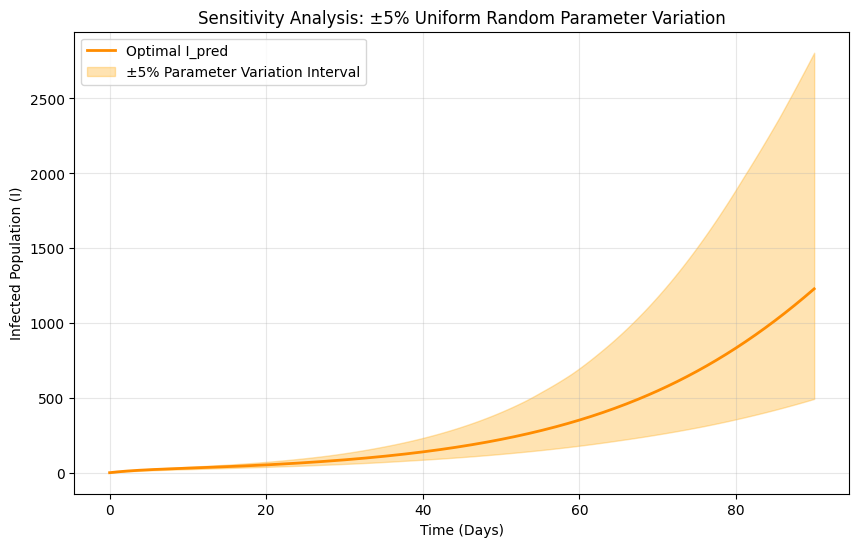

In [16]:

# ==========================================
# 4. PLOT THE RESULTS
# ==========================================
plt.figure(figsize=(10, 6))

# Plot the optimal prediction (from your base least_squares result)
plt.plot(t_fine, Id_p, label='Optimal I_pred', color='darkorange', linewidth=2)

# Shade the interval region
plt.fill_between(
    t_fine, 
    lower_bound_I, 
    upper_bound_I, 
    color='orange', 
    alpha=0.3, 
    label='±5% Parameter Variation Interval'
)

# Plot formatting
plt.xlabel('Time (Days)')
plt.ylabel('Infected Population (I)')
plt.title('Sensitivity Analysis: ±5% Uniform Random Parameter Variation')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.show()

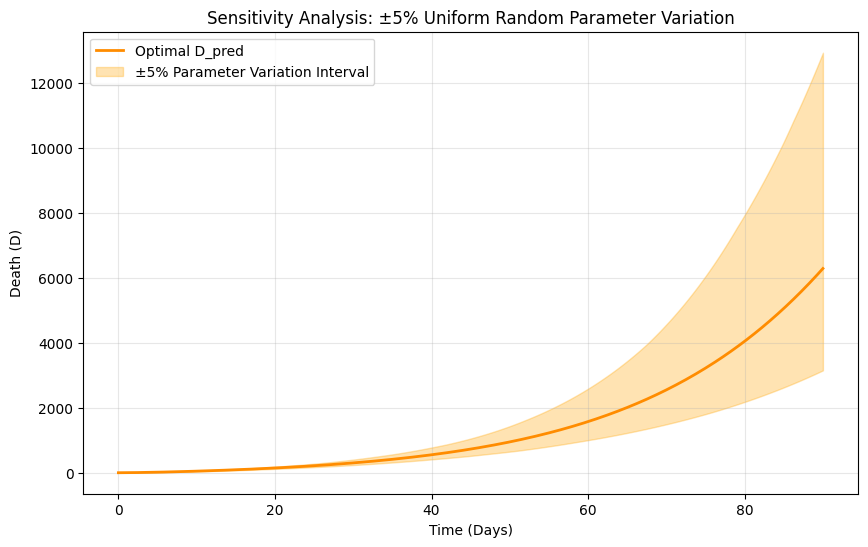

In [17]:

# ==========================================
# 4. PLOT THE RESULTS
# ==========================================
plt.figure(figsize=(10, 6))

# Plot the optimal prediction (from your base least_squares result)
plt.plot(t_fine, Dd_p, label='Optimal D_pred', color='darkorange', linewidth=2)

# Shade the interval region
plt.fill_between(
    t_fine, 
    lower_bound_D, 
    upper_bound_D, 
    color='orange', 
    alpha=0.3, 
    label='±5% Parameter Variation Interval'
)

# Plot formatting
plt.xlabel('Time (Days)')
plt.ylabel('Death (D)')
plt.title('Sensitivity Analysis: ±5% Uniform Random Parameter Variation')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.show()

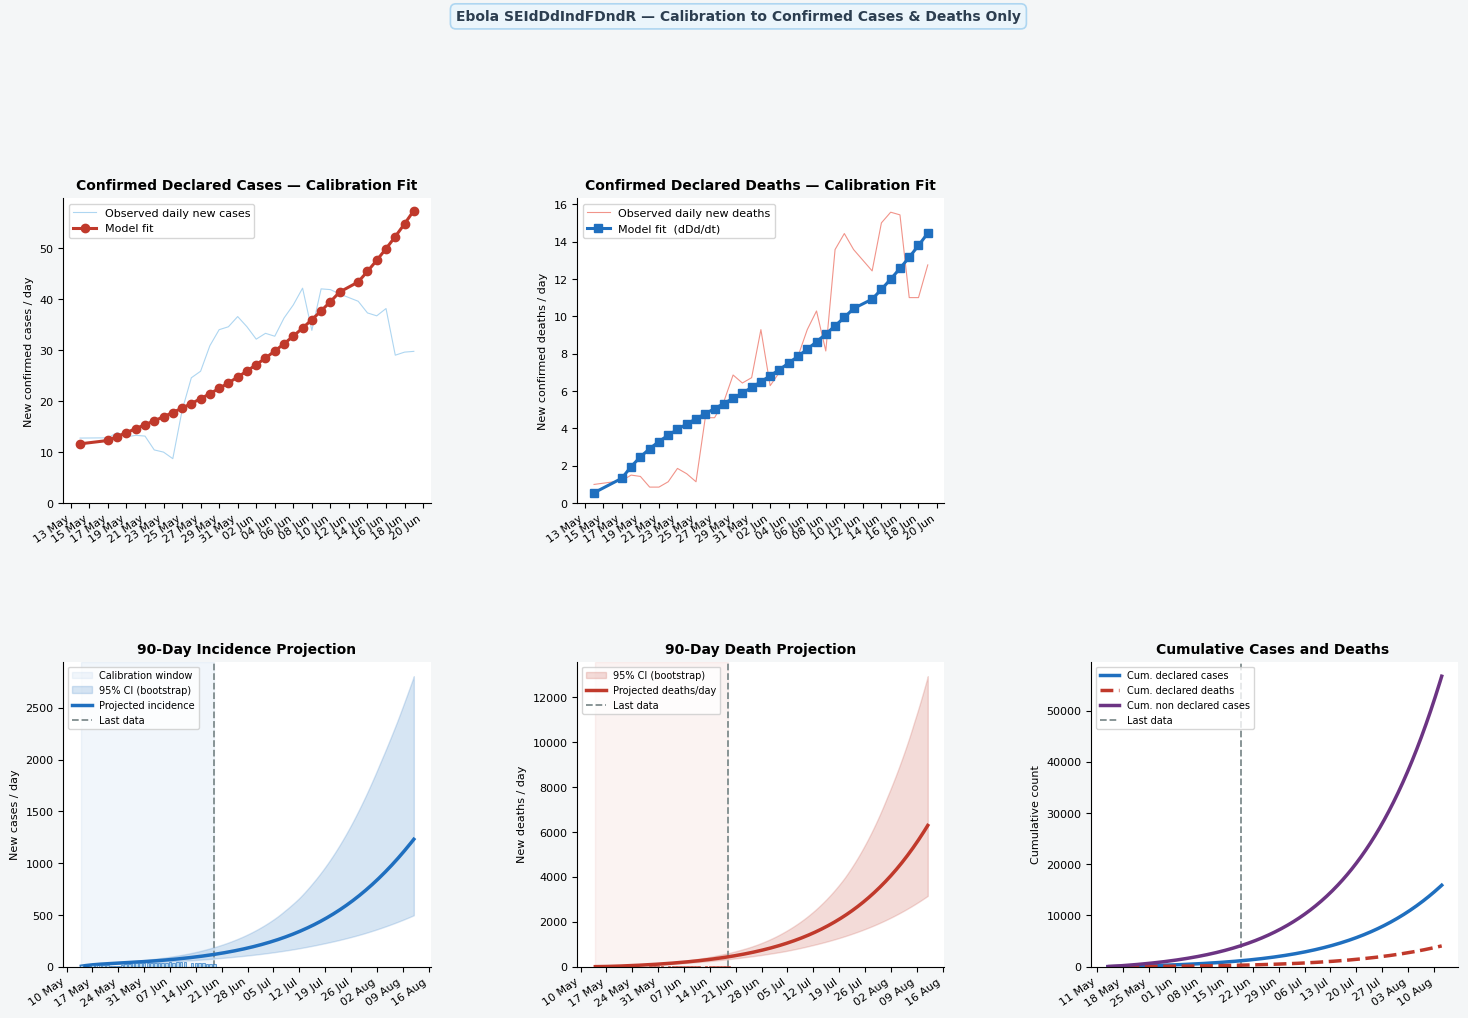

In [18]:
# ══════════════════════════════════════════════════════════════════════════
# 11.  PLOTS
# ══════════════════════════════════════════════════════════════════════════

BLUE   = '#1F6FBF';  LBLUE  = '#AED6F1'
RED    = '#C0392B';  LRED   = '#F1948A'
GREEN  = '#1A7A4A';  LGREEN = '#A9DFBF'
ORANGE = '#D35400';  GRAY   = '#7F8C8D'
PURPLE = '#6C3483'

def style(ax, interval=7):
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=interval))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)

def vline(ax, date, label=None, color=GRAY, ls='--', lw=1.3):
    ax.axvline(date, color=color, lw=lw, ls=ls,
               label=label, zorder=1)

last_obs = obs_dates[-1]

fig = plt.figure(figsize=(18, 16))
fig.patch.set_facecolor('#F4F6F7')
gs  = fig.add_gridspec(3, 3, hspace=0.52, wspace=0.40)

# ── [0,0]  CONFIRMED CASES FIT ─────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.plot(obs_dates, obs_cases,
       color=LBLUE, lw=0.8,
       label='Observed daily new cases')
ax.plot(obs_dates, fit_cases, 'o-', color=RED, lw=2.2, ms=6,
        label='Model fit', zorder=3)
ax.set_title('Confirmed Declared Cases — Calibration Fit',
             fontsize=10, fontweight='bold')
ax.set_ylabel('New confirmed cases / day', fontsize=8)
ax.legend(fontsize=8); ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
style(ax, interval=2)

# ── [0,1]  CONFIRMED DEATHS FIT ────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.plot(obs_dates, obs_deaths,
       color=LRED, lw=0.8,
       label='Observed daily new deaths')
ax.plot(obs_dates, fit_deaths, 's-', color=BLUE, lw=2.2, ms=6,
        label='Model fit  (dDd/dt)', zorder=3)
ax.set_title('Confirmed Declared Deaths — Calibration Fit',
             fontsize=10, fontweight='bold')
ax.set_ylabel('New confirmed deaths / day', fontsize=8)
ax.legend(fontsize=8); ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
style(ax, interval=2)


# ── [1,0]  90-DAY INCIDENCE PROJECTION  with 95% CI ───────────────────
ax = fig.add_subplot(gs[1, 0])
ax.axvspan(DATA_START, last_obs, alpha=0.06, color=BLUE,
           label='Calibration window')
ax.fill_between(proj_dates, lower_bound_I, upper_bound_I,
                color=BLUE, alpha=0.18, label='95% CI (bootstrap)')
ax.plot(proj_dates, Id_p, '-', color=BLUE, lw=2.5,
        label='Projected incidence')
ax.bar(obs_dates, obs_cases, color=LBLUE, edgecolor=BLUE,
       lw=0.5, width=0.7, zorder=2, alpha=0.9)
vline(ax, last_obs,  'Last data',                  color=GRAY)

ax.set_title('90-Day Incidence Projection', fontsize=10, fontweight='bold')
ax.set_ylabel('New cases / day', fontsize=8)
ax.legend(fontsize=7, loc='upper left'); ax.set_ylim(bottom=0)
style(ax)

# ── [1,1]  90-DAY DEATH PROJECTION  with 95% CI ───────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.axvspan(DATA_START, last_obs, alpha=0.06, color=RED)
ax.fill_between(proj_dates, lower_bound_D, upper_bound_D,
                color=RED, alpha=0.18, label='95% CI (bootstrap)')
ax.plot(proj_dates, Dd_p, '-', color=RED, lw=2.5,
        label='Projected deaths/day')
ax.bar(obs_dates, obs_deaths, color=LRED, edgecolor=RED,
       lw=0.5, width=0.7, zorder=2, alpha=0.9)
vline(ax, last_obs, 'Last data', color=GRAY)

ax.set_title('90-Day Death Projection', fontsize=10, fontweight='bold')
ax.set_ylabel('New deaths / day', fontsize=8)
ax.legend(fontsize=7); ax.set_ylim(bottom=0)
style(ax)

# ── [1,2]  CUMULATIVE CASES & DEATHS  with 95% CI ─────────────────────
ax = fig.add_subplot(gs[1, 2])

ax.plot(proj_dates, cum_cases_p, '-',  color=BLUE, lw=2.5, label='Cum. declared cases')
ax.plot(proj_dates, cum_deaths_p, '--', color=RED,  lw=2.5, label='Cum. declared deaths')
ax.plot(proj_dates, cum_casesnd_p, '-', color=PURPLE,  lw=2.5, label='Cum. non declared cases')

vline(ax, last_obs, 'Last data', color=GRAY)
ax.set_title('Cumulative Cases and Deaths ', fontsize=10, fontweight='bold')
ax.set_ylabel('Cumulative count', fontsize=8)
ax.legend(fontsize=7); ax.set_ylim(bottom=0)
style(ax)



# ── SUPER-TITLE ─────────────────────────────────────────────────────────
fig.text(
    0.5, 0.998,
    f"Ebola SEIdDdIndFDndR — Calibration to Confirmed Cases & Deaths Only",
    ha='center', va='top', fontsize=10, fontweight='bold', color='#2C3E50',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#EBF5FB',
              edgecolor='#AED6F1', lw=1.2)
)

plt.show()





Peak declared incidence: 1525.3 cases/day on 22 Sep 2026
Peak Id(t): 3135 persons on 25 Sep 2026


(0.0, 59534.21612255533)

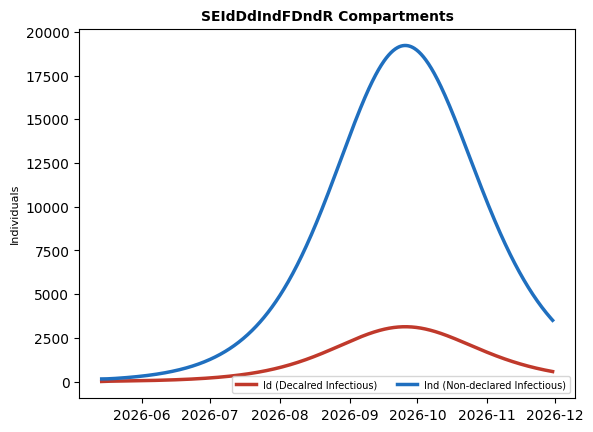

In [19]:
# ══════════════════════════════════════════════════════════════════════════
# 8.  PROJECTION (90 DAYS)
# ══════════════════════════════════════════════════════════════════════════

N_PROJ = 200
t_fine = np.linspace(0, N_PROJ, N_PROJ * 4 + 1)
sol_proj = model_hat.run((0., N_PROJ),
                         [S0_hat, E0_hat, Id0_hat, Ind0_hat, 0., 0., 0., 0.],
                         t_fine)

S_p, E_p, Id_p, Ind_p, F_p, R_p, Dd_p, Dnd_p = sol_proj.y
inc_p = model_hat.incidence_Id(sol_proj)
dead_p = model_hat.death_rate_Dd(sol_proj)
incnd_p = model_hat.incidence_Ind(sol_proj)

dt = t_fine[1] - t_fine[0]
cum_cases_p = np.cumsum(inc_p) * dt
cum_deaths_p = np.cumsum(dead_p) * dt
cum_casesnd_p = np.cumsum(incnd_p) * dt

proj_dates = [DATA_START + timedelta(days=float(t)) for t in t_fine]

# Find peaks
peak_inc_idx = np.argmax(inc_p)
peak_inc_date = proj_dates[peak_inc_idx]
peak_inc_val = inc_p[peak_inc_idx]

peak_Id_idx = np.argmax(Id_p)
peak_Id_date = proj_dates[peak_Id_idx]
peak_Id_val = Id_p[peak_Id_idx]


print(f"\nPeak declared incidence: {peak_inc_val:.1f} cases/day on {peak_inc_date.strftime('%d %b %Y')}")
print(f"Peak Id(t): {peak_Id_val:.0f} persons on {peak_Id_date.strftime('%d %b %Y')}")

#plt.plot(proj_dates, S_p, lw=2,   color=BLUE,   label='S (Susceptible)')
#plt.plot(proj_dates, E_p, lw=2,   color=ORANGE, label='E (Exposed)')
plt.plot(proj_dates, Id_p, lw=2.5, color=RED,    label='Id (Decalred Infectious)')
plt.plot(proj_dates, Ind_p, lw=2.5, color=BLUE,    label='Ind (Non-declared Infectious)')

#plt.plot(proj_dates, F_p, lw=1.8, color=PURPLE, label='F (Funeral)')
#plt.plot(proj_dates, R_p, lw=2,   color=GREEN,  label='R (Recovered)')
vline(ax, last_obs,    'Last data',  color=GRAY)
vline(ax, peak_Id_val,    'Peak of cases',  color=GRAY)
plt.title('SEIdDdIndFDndR Compartments',
             fontsize=10, fontweight='bold')
plt.ylabel('Individuals', fontsize=8)
plt.legend(fontsize=7, ncol=2); ax.set_ylim(bottom=0)

(0.0, 59534.21612255533)

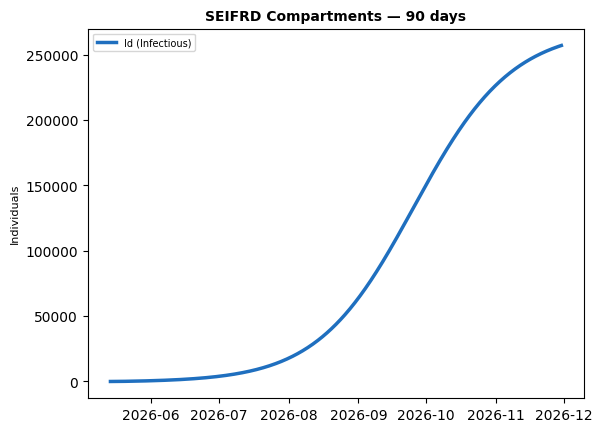

In [20]:

plt.plot(proj_dates, np.cumsum(Id_p) * dt, lw=2.5, color=BLUE,    label='Id (Infectious)')

#plt.plot(proj_dates, F_p, lw=1.8, color=PURPLE, label='F (Funeral)')
#plt.plot(proj_dates, R_p, lw=2,   color=GREEN,  label='R (Recovered)')
vline(ax, last_obs,    'Last data',  color=GRAY)
plt.title('SEIFRD Compartments — 90 days',
             fontsize=10, fontweight='bold')
plt.ylabel('Individuals', fontsize=8)
plt.legend(fontsize=7, ncol=2); ax.set_ylim(bottom=0)

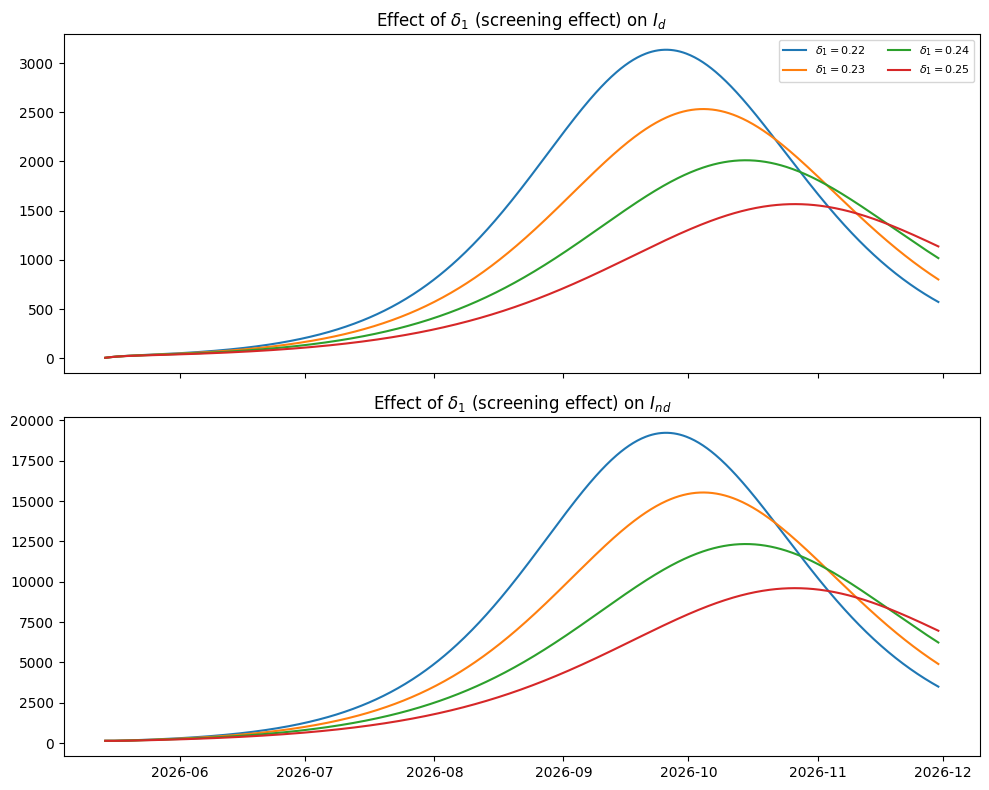

In [21]:
delta_values = np.arange(delta1_hat, 0.25, 0.01)

Id_solutions = []
Ind_solutions = []

for delta1 in delta_values:

    model = SEIDdIndFR(
        bId_hat, bInd_hat, bF_hat,
        alpha_hat, gamma_i_hat,
        delta1, mu_hat, gamma_f_hat
    )

    sol = model.run(
        (0., N_PROJ),
        [S0_hat, E0_hat, Id0_hat, Ind0_hat, 0., 0., 0., 0.],
        t_fine
    )

    Id_solutions.append(sol.y[2])
    Ind_solutions.append(sol.y[3])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,8), sharex=True)

for i, delta1 in enumerate(delta_values):
    ax1.plot(proj_dates, Id_solutions[i],
             label=fr'$\delta_1={delta1:.2f}$')

    ax2.plot(proj_dates, Ind_solutions[i],
             label=fr'$\delta_1={delta1:.2f}$')

ax1.set_title(r'Effect of $\delta_1$ (screening effect) on $I_d$')
ax2.set_title(r'Effect of $\delta_1$ (screening effect) on $I_{nd}$')

ax1.legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()